# Mbrain preprocessing

This workflow loads and filters the five Mbrain slices, aligns them to the T171 reference, computes ligand-receptor potential within each slice, trains scanVI, and saves one analysis-ready AnnData object. Configure all paths in `config.yaml` before execution.

In [ ]:
from pathlib import Path
import sys
import yaml

CWD = Path.cwd().resolve()
EXPERIMENT_DIR = CWD if (CWD / "config.yaml").is_file() else CWD / "experiments" / "Mbrain"
REPO_ROOT = EXPERIMENT_DIR.parents[1]
sys.path.append(str(REPO_ROOT / "src"))

CONFIG = yaml.safe_load(
    (EXPERIMENT_DIR / "config.yaml").read_text(encoding="utf-8")
)

def experiment_path(value):
    path = Path(value)
    return path if path.is_absolute() else (EXPERIMENT_DIR / path).resolve()

DATA_ROOT = experiment_path(CONFIG["data_root"])
RUN_ROOT = experiment_path(CONFIG["run_root"])
CHECKPOINT_ROOT = experiment_path(CONFIG["checkpoint_root"])
SCANVI_DIR = experiment_path(CONFIG["scanvi_dir"])
SCANVI_ADATA = SCANVI_DIR / "adata.h5ad"
LR_PAIRS = experiment_path(CONFIG["lr_pairs_path"])
DIFF_MAP = experiment_path(CONFIG["diff_map_path"]) if "diff_map_path" in CONFIG else None

DATA_ROOT.mkdir(parents=True, exist_ok=True)
RUN_ROOT.mkdir(parents=True, exist_ok=True)
CHECKPOINT_ROOT.mkdir(parents=True, exist_ok=True)


In [ ]:
import anndata as ad
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
import scvi
import seaborn as sns
import torch

from stvirtual.models.uot_alignment import register_slice_to_ref_robust
from stvirtual.utils import compute_lr_potential_per_sample

## Load and filter the slices

In [ ]:
sample_files = {
    "T168": "Mouse1_T168.h5ad",
    "T169": "Mouse1_T169.h5ad",
    "T170": "Mouse1_T170.h5ad",
    "T171": "Mouse1_T171.h5ad",
}
adatas = {}
for sample_id, filename in sample_files.items():
    sample_adata = sc.read_h5ad(DATA_ROOT / filename)
    sample_adata.var_names_make_unique()
    adatas[sample_id] = sample_adata

adata = ad.concat(adatas, label="sample")
adata.obs_names_make_unique()
print(adata.obs["sample"].value_counts())
adata

sample
T171    47683
T170    35753
T169    35068
T168    25746
Name: count, dtype: int64


<conda-env>/lib/python3.12/site-packages/anndata/_core/anndata.py:1791: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


AnnData object with n_obs × n_vars = 144250 × 20161
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'region', 'coor_x', 'coor_y', 'raw_x', 'raw_y', 'distance', 'area', 'Astrocyte', 'Bergmann', 'Choroid', 'Endothelial_mural', 'Endothelial_stalk', 'Ependymal', 'Fibroblast', 'Golgi', 'Granule', 'MLI1', 'MLI2', 'Macrophage', 'Microglia', 'ODC', 'OPC', 'PLI', 'Purkinje', 'UBC', 'cluster', 'annotation', 'sample'
    obsm: 'spatial'

In [ ]:
scvi.settings.seed = 0
sc.set_figure_params(figsize=(6, 6), frameon=False)
sns.set_theme()
torch.set_float32_matmul_precision("high")
sc.settings.figdir = RUN_ROOT / "figures"
sc.settings.figdir.mkdir(parents=True, exist_ok=True)
print("scvi-tools version:", scvi.__version__)

Seed set to 0


scvi-tools version: 1.4.0


In [ ]:
sc.pp.filter_genes(adata, min_counts=3)
sc.pp.filter_cells(adata, min_genes=200)
adata.layers["counts"] = adata.X.copy()
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)
adata.raw = adata

adata.obs["annotation"] = adata.obs["annotation"].astype("category")
if "Unknown" not in adata.obs["annotation"].cat.categories:
    adata.obs["annotation"] = adata.obs["annotation"].cat.add_categories(["Unknown"])

## Align all slices to T171

In [ ]:
REFERENCE_SAMPLE = "T171"
COORD_COLUMNS = ["coor_x", "coor_y"]
coordinates = adata.obs[COORD_COLUMNS].to_numpy(dtype=np.float32)
coordinate_min = np.nanmin(coordinates, axis=0)
coordinate_scale = np.nanmax(coordinates, axis=0) - coordinate_min
coordinate_scale[coordinate_scale == 0] = 1.0

def normalize_coordinates(values):
    return (values.astype(np.float32, copy=False) - coordinate_min) / coordinate_scale

def restore_coordinates(values):
    return values.astype(np.float32, copy=False) * coordinate_scale + coordinate_min

sample_values = adata.obs["sample"].astype(str).to_numpy()
reference_mask = sample_values == REFERENCE_SAMPLE
reference_coordinates = coordinates[reference_mask]
reference_normalized = normalize_coordinates(reference_coordinates)
reference_annotations = adata.obs.loc[reference_mask, "annotation"].astype(str).to_numpy()
aligned_normalized = np.full_like(coordinates, np.nan, dtype=np.float32)
aligned_normalized[reference_mask] = reference_normalized
alignment_info = {}

for sample_id in pd.unique(sample_values):
    if sample_id == REFERENCE_SAMPLE:
        continue
    sample_mask = sample_values == sample_id
    sample_coordinates = normalize_coordinates(coordinates[sample_mask])
    sample_annotations = adata.obs.loc[sample_mask, "annotation"].astype(str).to_numpy()
    aligned, info = register_slice_to_ref_robust(
        sample_coordinates,
        reference_normalized,
        sample_annotations,
        reference_annotations,
        n_sub=10000,
        reg=None,
        reg_m=1.0,
        seed=2025,
        icp_iter=40,
        verbose=True,
    )
    aligned_normalized[sample_mask] = aligned.astype(np.float32)
    alignment_info[sample_id] = info

aligned_coordinates = restore_coordinates(aligned_normalized)
adata.obs["cx_aligned"] = aligned_coordinates[:, 0]
adata.obs["cy_aligned"] = aligned_coordinates[:, 1]
adata.obs["cx_aligned_norm"] = aligned_normalized[:, 0]
adata.obs["cy_aligned_norm"] = aligned_normalized[:, 1]
adata.obsm["spatial_aligned"] = aligned_coordinates
adata.uns["alignment_reference"] = REFERENCE_SAMPLE
print("Aligned coordinates:", adata.obsm["spatial_aligned"].shape)

UOT init:   0%|          | 0/18 [04:34<?, ?it/s, best=0.06037, reg=0.0142, score=0.06245, th=0.0146, trial=18] 


[UOT init] BEST score=0.060373 reg=0.0142402 theta=0.0195 t=[-0.14298338476496641, 0.16192431336858848]


UOT init:   0%|          | 0/18 [04:28<?, ?it/s, best=0.03355, reg=0.0158, score=0.03373, th=0.0105, trial=18]  


[UOT init] BEST score=0.033546 reg=0.0157835 theta=0.0148 t=[-0.08991107395907882, 0.05492404858464256]


UOT init:   0%|          | 0/18 [04:17<?, ?it/s, best=0.02089, reg=0.0163, score=0.02209, th=-0.0209, trial=18] 


[UOT init] BEST score=0.020889 reg=0.0162672 theta=-0.0167 t=[-0.04253657651500886, 0.07931120439405465]


ICP refine: 100%|██████████| 40/40 [00:02<00:00, 16.85it/s, cls=1, med=0.001925, p90=0.02151, th=-0.0268, tx=-0.0156, ty=0.044]  

Aligned coordinates: (138384, 2)


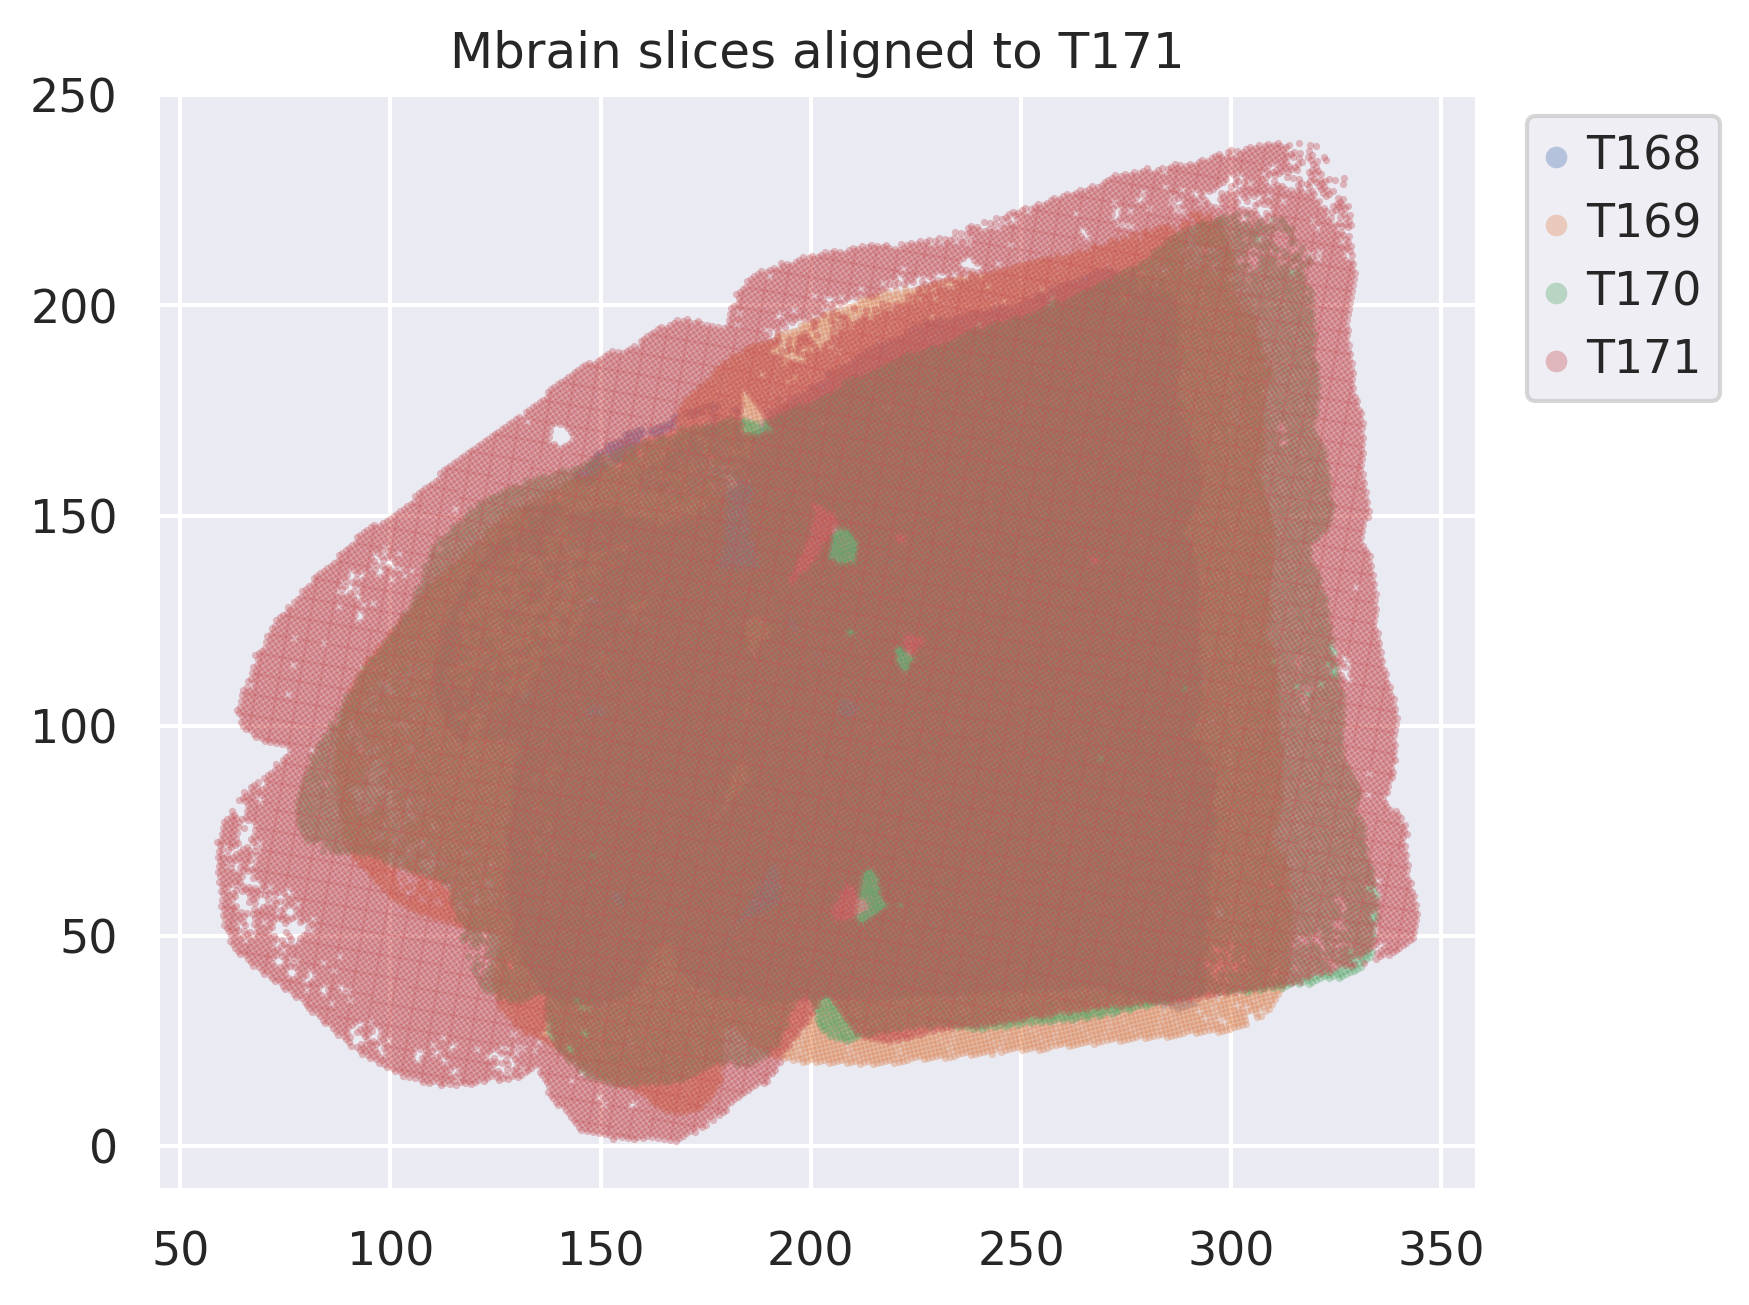

In [ ]:
fig, ax = plt.subplots(figsize=(6, 6), dpi=150)
for sample_id in pd.unique(sample_values):
    mask = sample_values == sample_id
    ax.scatter(
        aligned_coordinates[mask, 0],
        aligned_coordinates[mask, 1],
        s=3,
        alpha=0.35,
        linewidths=0,
        label=sample_id,
    )
ax.set_aspect("equal")
ax.set_title(f"Mbrain slices aligned to {REFERENCE_SAMPLE}")
ax.legend(markerscale=3, bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()

## Compute ligand-receptor potential

In [ ]:
lr_pairs = pd.read_csv(LR_PAIRS)
adata = compute_lr_potential_per_sample(
    adata,
    lr_pairs,
    sample_key="sample",
    coords_key="spatial_aligned",
    layer="counts",
    k=6,
    use_cpm=True,
    hill=True,
    pair_chunk=64,
)
adata.obs[["LR_potential", "LR_potential_z"]].describe()

,LR_potential,LR_potential_z
count,138384.000000,1.383840e+05
mean,0.000000,7.056903e-09
std,1.000002,1.000004e+00
min,-1.036619,-1.036620e+00
25%,-0.757001,-7.570020e-01
50%,-0.260748,-2.607484e-01
75%,0.476493,4.764936e-01
max,10.479101,1.047911e+01


## Train scanVI and store the latent representation

In [ ]:
sc.pp.highly_variable_genes(
    adata,
    n_top_genes=5000,
    layer="counts",
    flavor="seurat_v3",
    batch_key="sample",
)

In [ ]:
scvi.model.SCANVI.setup_anndata(
    adata,
    layer="counts",
    labels_key="annotation",
    unlabeled_category="Unknown",
    batch_key="sample",
)
model = scvi.model.SCANVI(adata)
model.train()

INFO     Training for 58 epochs.                                                                                   


Trainer will use only 1 of 2 GPUs because it is running inside an interactive / notebook environment. You may try to set `Trainer(devices=2)` but please note that multi-GPU inside interactive / notebook environments is considered experimental and unstable. Your mileage may vary.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
<conda-env>/lib/python3.12/site-packages/scvi/dataloaders/_data_splitting.py:443: UserWarning: Last batch will have a small size of 2 samples. Consider changing settings.batch_size or batch_size in model.train from currently 128 to avoid errors during model training.
  n_labeled_train, n_labeled_val = validate_data_split(
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]
<conda-env>/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:433: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argumen

Training:   0%|          | 0/58 [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=58` reached.


In [ ]:
model_dir = SCANVI_DIR
SCVI_LATENT_KEY = CONFIG.get("latent_key", "X_scanVI")
adata.obsm[SCVI_LATENT_KEY] = model.get_latent_representation()
adata.obsm[SCVI_LATENT_KEY].shape


(138384, 10)

## Quality-control views

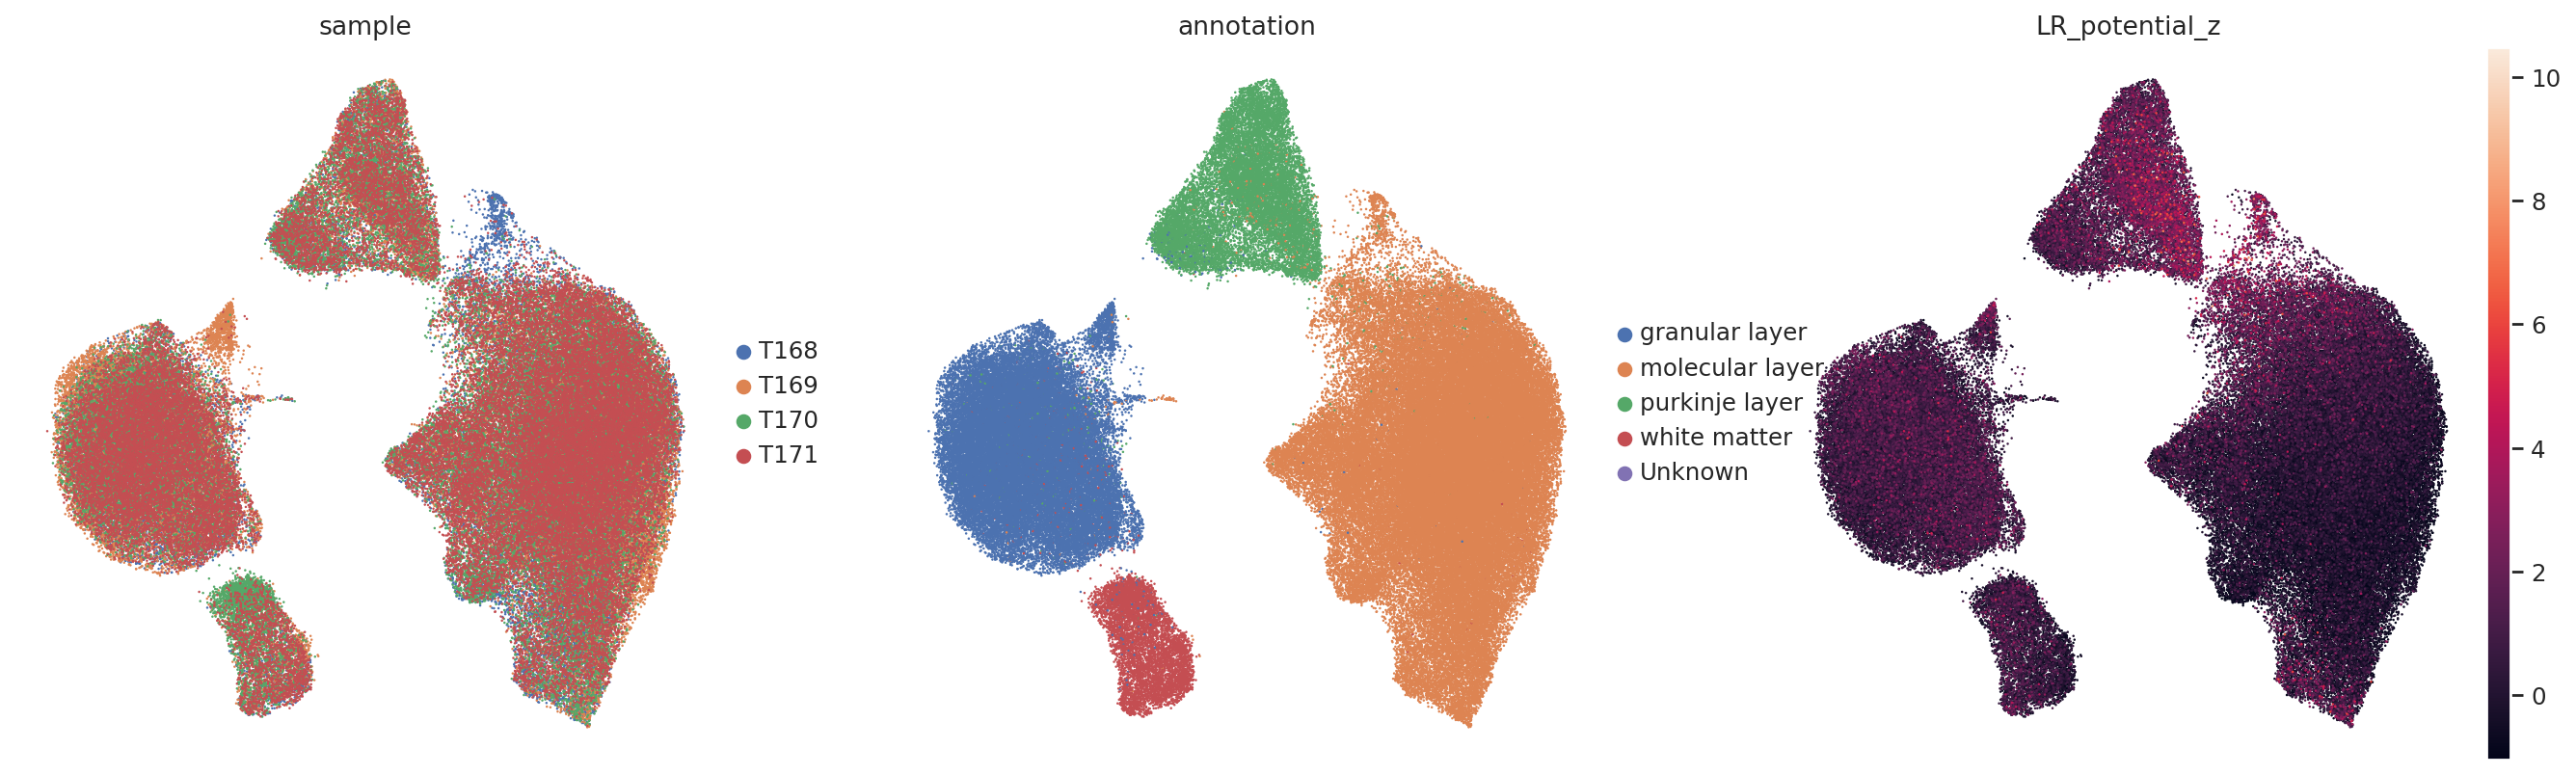

In [ ]:
sc.pp.neighbors(adata, use_rep=SCVI_LATENT_KEY)
sc.tl.umap(adata, min_dist=0.3)
sc.pl.umap(adata, color=["sample", "annotation", "LR_potential_z"], frameon=False, size=5)

/tmp/ipykernel_2933600/2177084550.py:2: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(adata, key_added=SCVI_CLUSTERS_KEY, resolution=0.5)


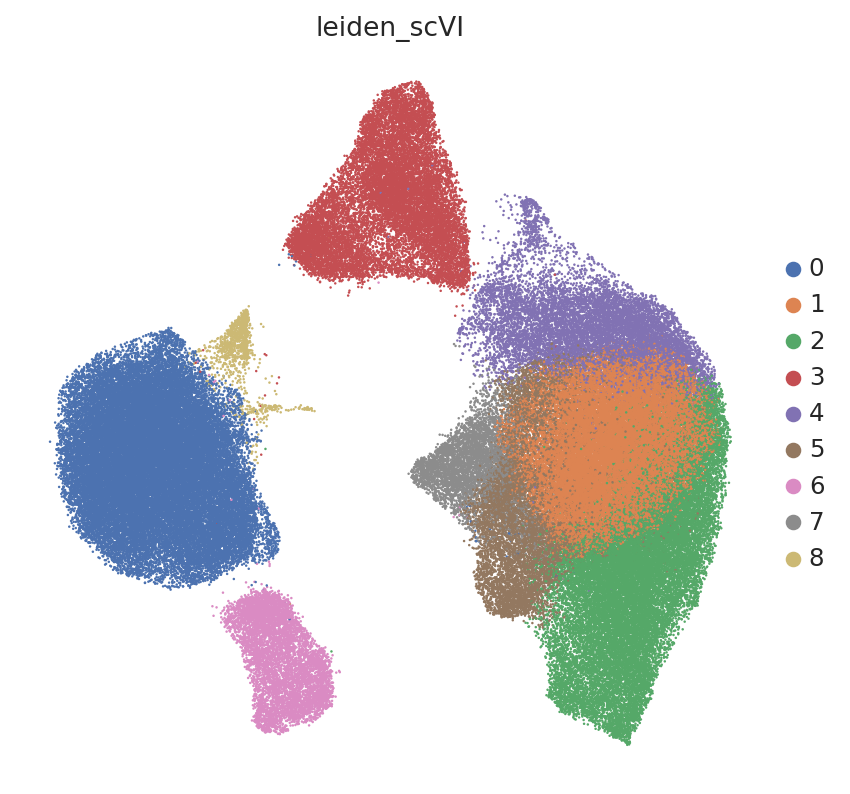

In [ ]:
SCVI_CLUSTERS_KEY = "leiden_scVI"
sc.tl.leiden(adata, key_added=SCVI_CLUSTERS_KEY, resolution=0.5)
sc.pl.umap(adata, color=[SCVI_CLUSTERS_KEY], frameon=False, size=5)

## Save the analysis-ready object

In [ ]:
model.save(model_dir, overwrite=True, save_anndata=True)
print(f"Saved model-ready AnnData: {SCANVI_ADATA}")
adata


Saved model-ready AnnData: <repo>/experiments/Mbrain/artifacts/checkpoints/scanvi/adata.h5ad


AnnData object with n_obs × n_vars = 138384 × 20161
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'region', 'coor_x', 'coor_y', 'raw_x', 'raw_y', 'distance', 'area', 'Astrocyte', 'Bergmann', 'Choroid', 'Endothelial_mural', 'Endothelial_stalk', 'Ependymal', 'Fibroblast', 'Golgi', 'Granule', 'MLI1', 'MLI2', 'Macrophage', 'Microglia', 'ODC', 'OPC', 'PLI', 'Purkinje', 'UBC', 'cluster', 'annotation', 'sample', 'n_genes', 'cx_aligned', 'cy_aligned', 'cx_aligned_norm', 'cy_aligned_norm', 'LR_potential', 'LR_potential_z', '_scvi_batch', '_scvi_labels', 'leiden_scVI'
    var: 'n_counts', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'highly_variable_nbatches'
    uns: 'log1p', 'alignment_reference', 'hvg', '_scvi_uuid', '_scvi_manager_uuid', 'neighbors', 'umap', 'sample_colors', 'annotation_colors', 'leiden_scVI', 'leiden_scVI_colors'
    obsm: 'spatial', 'spatial_aligned', 'X_scanVI', 'X_umap'
    layers: 'counts'
    obsp: 'distances', 'connectiviti